# Dataset overview

Estatísticas globais do `data/items.parquet`: cobertura, distribuições, profundidade média da história, items mais valiosos.

In [1]:
import polars as pl
import pyarrow.parquet as pq
import os

PATH = "../data/items.parquet"
pq_file = pq.ParquetFile(PATH)
print(f"Rows: {pq_file.metadata.num_rows:,}")
print(f"Columns: {pq_file.metadata.num_columns}")
print(f"Size: {pq_file.metadata.serialized_size/1024:.1f} KB (metadata)")
print(f"File size: {os.path.getsize(PATH)/1024/1024:.1f} MB")

Rows: 15,919
Columns: 52
Size: 14.7 KB (metadata)
File size: 745.4 MB


## Cobertura por tipo (price_series / price_ohlc / keyfigures não-nulos)

In [2]:
lf = pl.scan_parquet("../data/items.parquet")

# Projection pushdown: das colunas nested só lê o bitmap de nulos
base = (
    lf.select([
        "name", "weapon", "type", "quality", "collection",
        pl.col("price_series").is_not_null().alias("has_series"),
        pl.col("price_ohlc").is_not_null().alias("has_ohlc"),
        pl.col("keyfigures").is_not_null().alias("has_kf"),
    ])
    .with_columns(
        (pl.col("has_series") | pl.col("has_ohlc") | pl.col("has_kf")).alias("has_any")
    )
    .collect()
)

(
    base.select(["has_series", "has_ohlc", "has_kf", "has_any"])
        .mean()
        .transpose(include_header=True, header_name="flag", column_names=["pct"])
        .with_columns((pl.col("pct") * 100).round(1))
)

flag,pct
str,f64
"""has_series""",71.8
"""has_ohlc""",21.6
"""has_kf""",90.9
"""has_any""",96.5


In [3]:
# Cobertura por type
(
    base.group_by("type")
        .agg([
            pl.len().alias("total"),
            pl.col("has_any").sum().alias("with_data"),
        ])
        .with_columns((pl.col("with_data") / pl.col("total") * 100).round(1).alias("coverage_%"))
        .sort("total", descending=True)
)

type,total,with_data,coverage_%
str,u32,u32,f64
"""Knife""",3397,3135,92.3
"""Pistol""",3275,3264,99.7
"""Rifle""",2543,2530,99.5
"""SMG""",2315,2308,99.7
"""Shotgun""",1271,1268,99.8
…,…,…,…
"""Key""",32,22,68.8
"""Gift""",3,3,100.0
"""Tool""",2,1,50.0


In [4]:
# Top weapons por número de items
(
    base.group_by("weapon")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .head(15)
)

weapon,count
str,u32
"""Unknown""",1523
"""AK-47""",475
"""MAC-10""",456
"""P250""",443
"""P90""",426
…,…
"""AUG""",348
"""UMP-45""",347
"""USP-S""",346


## Profundidade da história por item

In [5]:
# Profundidade — list.len lê só os offsets, não materializa os elementos
hist = (
    pl.scan_parquet("../data/items.parquet")
      .select([
          pl.col("price_series").list.len().fill_null(0).alias("series_len"),
          pl.col("price_ohlc").list.len().fill_null(0).alias("ohlc_len"),
      ])
      .with_columns(
          pl.max_horizontal("series_len", "ohlc_len").alias("history_len")
      )
      .collect()
)

hist.filter(pl.col("history_len") > 0).select("history_len").describe()

statistic,history_len
str,f64
"""count""",14865.0
"""null_count""",0.0
"""mean""",11823.99556
"""std""",10801.54369
"""min""",1.0
"""25%""",1638.0
"""50%""",8828.0
"""75%""",20890.0
"""max""",35979.0


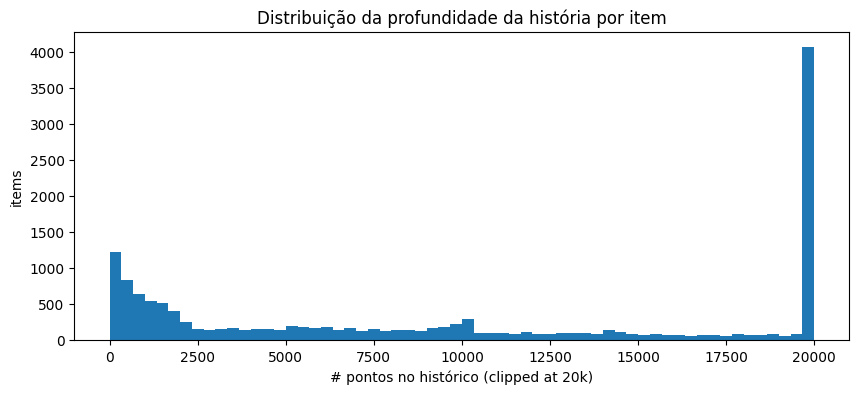

In [6]:
import matplotlib.pyplot as plt

vals = (
    hist.filter(pl.col("history_len") > 0)
        .select(pl.col("history_len").clip(upper_bound=20000))
        .to_series()
        .to_numpy()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(vals, bins=60)
ax.set_xlabel("# pontos no histórico (clipped at 20k)")
ax.set_ylabel("items")
ax.set_title("Distribuição da profundidade da história por item")
plt.show()

## Top 20 items mais caros (Steam Market, current_price)

In [7]:
# Steam current_price — acesso por struct, sem desserializar dicts em Python
top_steam = (
    pl.scan_parquet("../data/items.parquet")
      .select([
          "name", "weapon", "quality",
          pl.col("keyfigures").struct.field("steam").struct.field("current_price").alias("steam_price"),
      ])
      .filter(pl.col("steam_price").is_not_null())
      .sort("steam_price", descending=True)
      .head(20)
      .collect()
)
top_steam

name,weapon,quality,steam_price
str,str,str,f64
"""AK-47 | Hydroponic (Field-Test…","""AK-47""","""Classified""",2099.44
"""Souvenir M4A1-S | Welcome to t…","""M4A1-S""","""Covert""",2098.89
"""★ Karambit | Stained (Factory …","""Karambit""","""Covert""",2062.98
"""★ StatTrak™ Karambit | Lore (F…","""Karambit""","""Covert""",2048.81
"""★ Karambit | Scorched (Battle-…","""Karambit""","""Covert""",2022.65
…,…,…,…
"""★ StatTrak™ M9 Bayonet | Doppl…","""M9 Bayonet""","""Covert""",1915.75
"""★ StatTrak™ M9 Bayonet | Gamma…","""M9 Bayonet""","""Covert""",1907.67
"""★ StatTrak™ M9 Bayonet | Case …","""M9 Bayonet""","""Covert""",1865.31


## Comparação de preço entre marketplaces (top items)

In [8]:
marketplaces = ["steam", "skinport", "skinbaron", "csmoney", "skinswap", "haloskins", "uuskins"]

mp_df = (
    pl.scan_parquet("../data/items.parquet")
      .select(
          [pl.col("name")] + [
              pl.col("keyfigures").struct.field(mp).struct.field("current_price").alias(mp)
              for mp in marketplaces
          ]
      )
      .filter(pl.col("steam").is_not_null())
      .sort("steam", descending=True)
      .head(10)
      .collect()
)
mp_df

name,steam,skinport,skinbaron,csmoney,skinswap,haloskins,uuskins
str,f64,f64,f64,f64,f64,f64,f64
"""AK-47 | Hydroponic (Field-Test…",2099.44,1406.22,1861.88,1270.11,1298.56,1623.27,1310.02
"""Souvenir M4A1-S | Welcome to t…",2098.89,870.98,1046.8,857.51,791.99,1195.11,812.38
"""★ Karambit | Stained (Factory …",2062.98,1192.75,1173.83,833.35,803.01,1293.25,823.9
"""★ StatTrak™ Karambit | Lore (F…",2048.81,727.94,615.86,642.31,594.55,971.14,610.02
"""★ Karambit | Scorched (Battle-…",2022.65,461.31,460.75,408.74,382.57,435.73,392.52
"""AWP | Desert Hydra (Field-Test…",2004.04,1256.53,1850.23,1178.54,1055.11,1712.92,1082.57
"""★ StatTrak™ M9 Bayonet | Damas…",1995.56,619.0,822.5,560.0,498.97,716.32,511.95
"""P90 | Astral Jörmungandr (Batt…",1960.64,null,null,712.24,446.35,null,null
"""★ Butterfly Knife | Slaughter …",1960.43,1239.21,1281.81,1194.26,1056.82,1490.92,1084.32
